<a href="https://colab.research.google.com/github/Salsabila-002/UAS_BIGDATA_KELOMPOK-10/blob/main/Project_UAS_Analisis_Dataset_Kelompok_10_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##UAS PRAKTIKUM BIG DATA
1. Salsabila Fitri Ramadhani - 2310511002
2. Najwa Khaylawati - 2310511008
3. Nurhaliza - 2310511028

# Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Load Dataset Hasil ETL Pentaho

In [36]:
from google.colab import files
uploaded = files.upload()

Saving output_retail.csv to output_retail (1).csv


In [37]:
df = pd.read_csv('output_retail.csv', sep=';', engine='python')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010,425,17850,United Kingdom,2550.0
1,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010,765,17850,United Kingdom,1530.0
2,536365,71053,WHITE METAL LANTERN,6,01/12/2010,339,17850,United Kingdom,2034.0
3,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010,339,17850,United Kingdom,2034.0
4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010,339,17850,United Kingdom,2034.0


# Data Quality

In [38]:
df.shape

(392797, 9)

In [39]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
TotalPrice,0


In [40]:
df.duplicated().sum()

np.int64(105)

In [41]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Mengecek ulang jumlah data duplikat
df.duplicated().sum()

np.int64(0)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 392796
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   Price        392692 non-null  object 
 6   Customer ID  392692 non-null  int64  
 7   Country      392692 non-null  object 
 8   TotalPrice   392692 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 30.0+ MB


In [43]:
# Convert Price ke numeric
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Membuat Total Revenue
df['TotalRevenue'] = (
    df['Quantity'] * df['Price']
)

print("\nPreprocessing Selesai")


Preprocessing Selesai


In [44]:
X = df[
    ['Quantity', 'Price', 'TotalRevenue']
].copy()

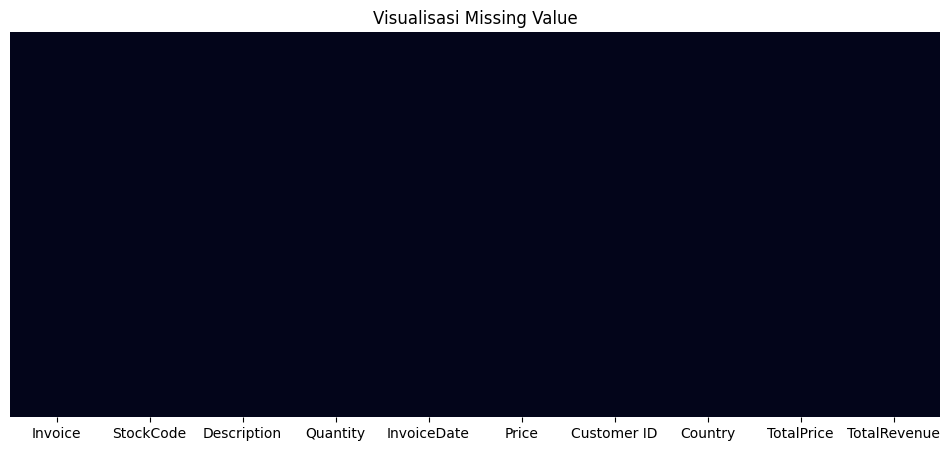

In [45]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Visualisasi Missing Value')

plt.show()

# Data Descriptive

In [46]:
print("\nStatistik Deskriptif:")
print(df[['Quantity', 'Price', 'TotalRevenue']].describe())


Statistik Deskriptif:
            Quantity          Price  TotalRevenue
count  392692.000000  392692.000000  3.926920e+05
mean       13.119699     226.571959  1.961791e+03
std       180.492832     208.584317  3.021920e+04
min         1.000000       1.000000  1.000000e+00
25%         2.000000      85.000000  3.300000e+02
50%         6.000000     165.000000  1.008000e+03
75%        12.000000     295.000000  1.770000e+03
max     80995.000000     998.000000  1.684696e+07


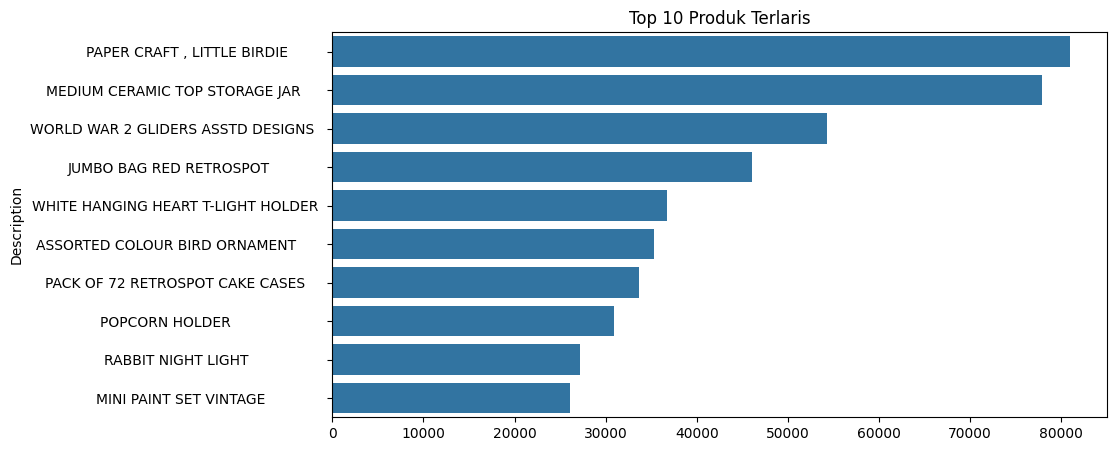

In [47]:
top_product = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_product.values,
    y=top_product.index
)

plt.title("Top 10 Produk Terlaris")
plt.show()

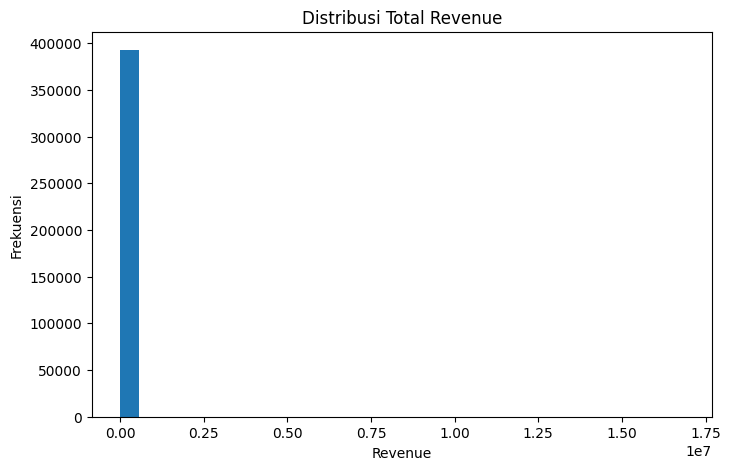

In [48]:
plt.figure(figsize=(8,5))

plt.hist(
    df['TotalRevenue'],
    bins=30
)

plt.title('Distribusi Total Revenue')

plt.xlabel('Revenue')

plt.ylabel('Frekuensi')

plt.show()

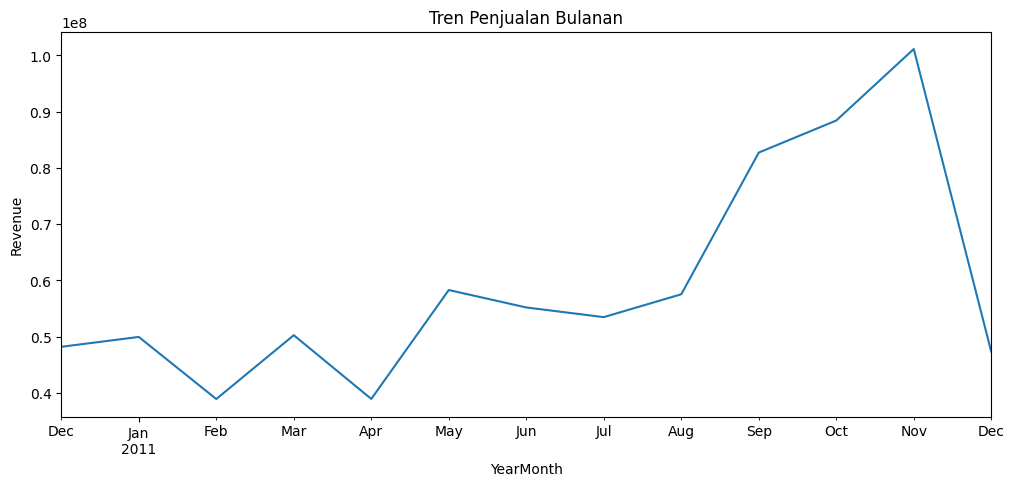

In [50]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

df['YearMonth'] = (
    df['InvoiceDate']
    .dt.to_period('M')
)

monthly_sales = (
    df.groupby('YearMonth')
    ['TotalRevenue']
    .sum()
)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Tren Penjualan Bulanan")
plt.ylabel("Revenue")
plt.show()

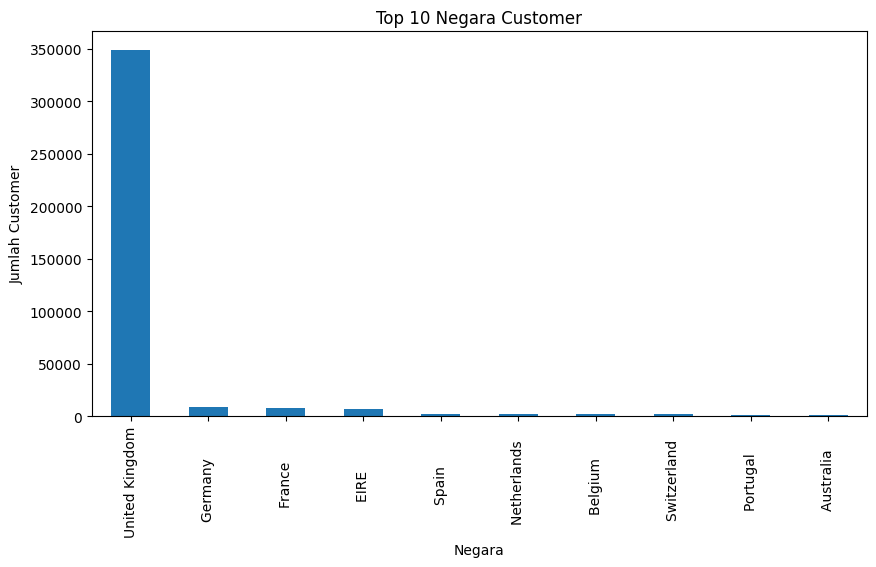

In [51]:
# Negara customer terbanyak
top_country = (
    df['Country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_country.plot(kind='bar')

plt.title('Top 10 Negara Customer')

plt.xlabel('Negara')

plt.ylabel('Jumlah Customer')

plt.show()

# CUSTOMER SEGMENTATION

# RFM Analysis

In [52]:
snapshot_date = (
    df['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby('Customer ID').agg({

    'InvoiceDate':
        lambda x:
        (snapshot_date - x.max()).days,

    'Invoice':'nunique',

    'TotalRevenue':'sum'

}).reset_index()

In [53]:
rfm.columns = [

    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'

]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,7718360.000
1,12347,3,7,406386.125
2,12348,76,4,144084.000
3,12349,19,1,124879.800
4,12350,311,1,20408.000


In [54]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4.338000e+03
mean,15300.408022,93.059474,4.272015,1.775887e+05
std,1721.808492,100.012264,7.697998,7.790757e+05
min,12346.000000,1.000000,1.000000,1.275000e+00
25%,13813.250000,18.000000,1.000000,2.606930e+04
50%,15299.500000,51.000000,2.000000,5.871979e+04
75%,16778.750000,142.750000,5.000000,1.456666e+05
max,18287.000000,374.000000,209.000000,2.584594e+07


# Deteksi Outlier

In [55]:
for col in ['Recency', 'Frequency', 'Monetary']:

    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outlier = rfm[
        (rfm[col] < lower) |
        (rfm[col] > upper)
    ]

    print(
        f"{col}: {len(outlier)} outlier"
    )

Recency: 155 outlier
Frequency: 285 outlier
Monetary: 419 outlier


In [27]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(

    rfm[
        ['Recency',
         'Frequency',
         'Monetary']
    ]

)

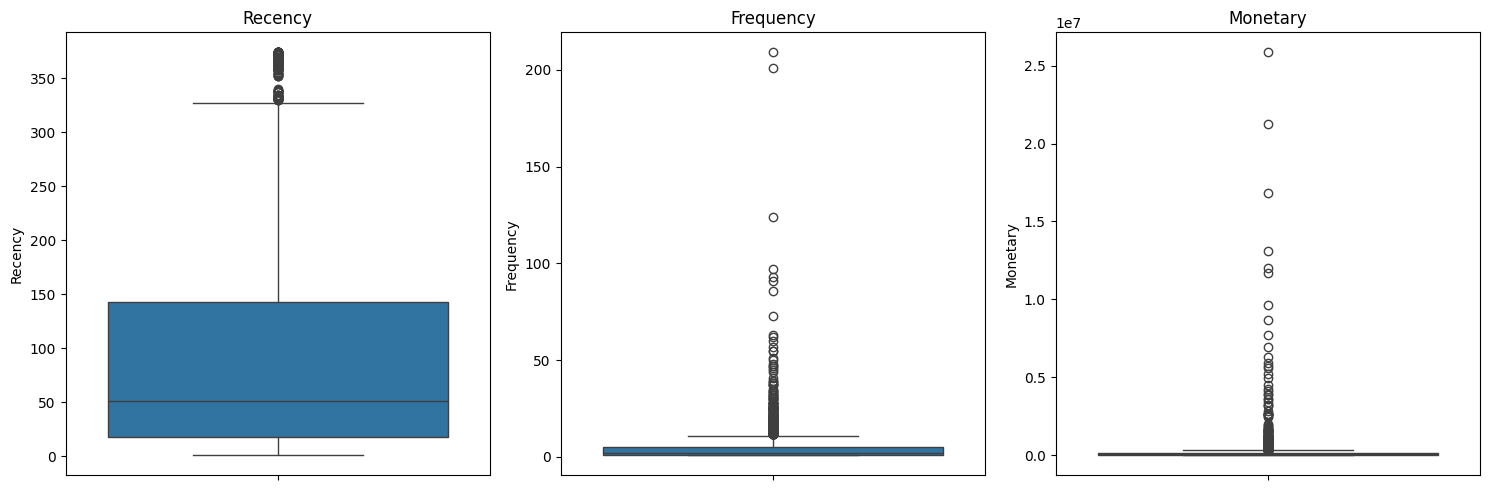

In [56]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])
plt.title('Recency')

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])
plt.title('Frequency')

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])
plt.title('Monetary')

plt.tight_layout()
plt.show()

# ELBOW Method

In [57]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(
        model.inertia_
    )

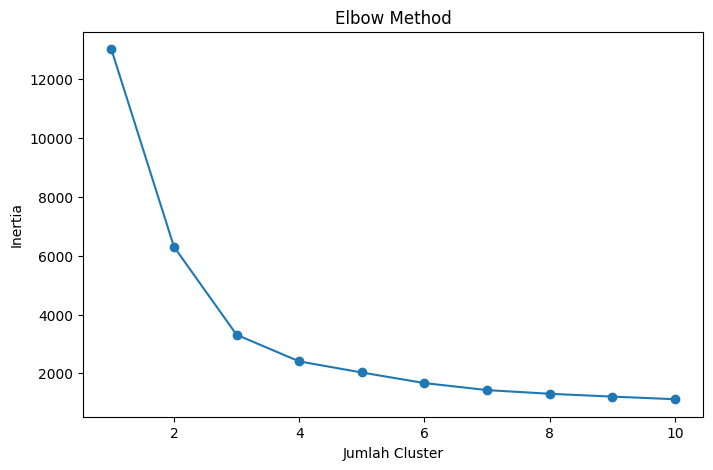

In [58]:
#Visualisasi ELBOW METHOD
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')

plt.show()

# Silhouette Score

In [59]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        rfm_scaled
    )

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K={k} | Score={score:.4f}"
    )

K=2 | Score=0.5032
K=3 | Score=0.5070
K=4 | Score=0.4727
K=5 | Score=0.4240
K=6 | Score=0.4180
K=7 | Score=0.4160
K=8 | Score=0.3960
K=9 | Score=0.3798
K=10 | Score=0.3571


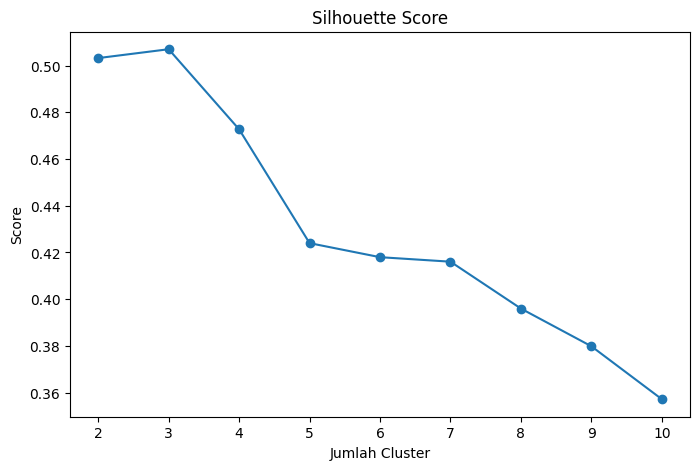

In [60]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title(
    'Silhouette Score'
)

plt.xlabel(
    'Jumlah Cluster'
)

plt.ylabel(
    'Score'
)

plt.show()

# K-Means Clustering

In [62]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print(rfm[['Recency', 'Frequency', 'Monetary', 'Cluster']].head(10))

   Recency  Frequency     Monetary  Cluster
0      326          1  7718360.000        2
1        3          7   406386.125        1
2       76          4   144084.000        0
3       19          1   124879.800        0
4      311          1    20408.000        2
5       37          8   123373.520        1
6      205          1     8900.000        2
7      233          1    97608.675        2
8      215          1    43392.550        2
9       23          3   195905.215        0


# Profil Cluster

In [63]:
cluster_profile = (

    rfm.groupby('Cluster')

    .agg({

        'Recency':'mean',

        'Frequency':'mean',

        'Monetary':'mean',

        'CustomerID':'count'

    })

)

cluster_profile

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,49.738014,2.464897,64399.704646,2336
1,27.170324,11.739812,600667.400888,957
2,250.241148,1.472727,43161.069414,1045


# Visualisasi Profil Cluster

In [66]:
cluster_profile = rfm.groupby('Cluster').mean()

print("\nProfil Cluster:")
print(cluster_profile)


Profil Cluster:
           CustomerID     Recency  Frequency       Monetary
Cluster                                                    
0        15322.590753   49.738014   2.464897   64399.704646
1        15186.836991   27.170324  11.739812  600667.400888
2        15354.827751  250.241148   1.472727   43161.069414


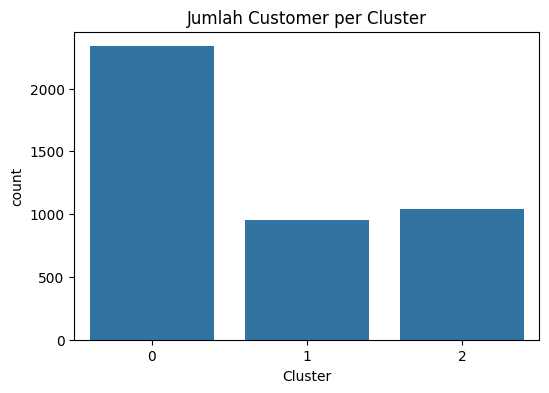

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Cluster',
    data=rfm
)

plt.title(
    'Jumlah Customer per Cluster'
)

plt.show()

# PCA

In [67]:
pca = PCA(
    n_components=2
)

rfm_pca = pca.fit_transform(
    rfm_scaled
)

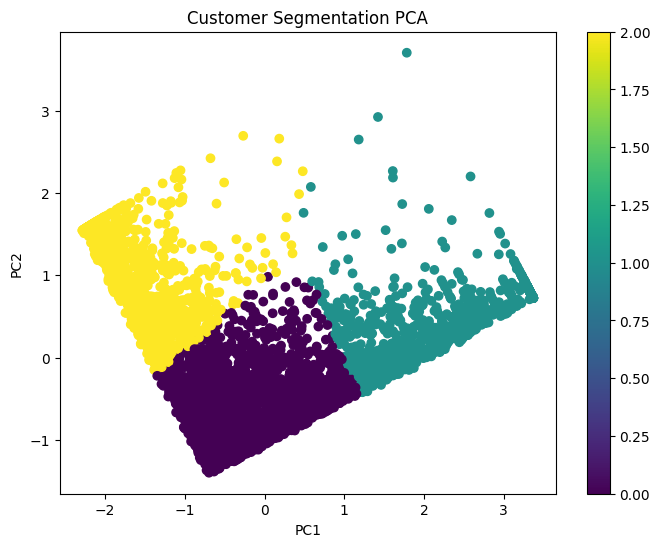

In [68]:
plt.figure(figsize=(8,6))

plt.scatter(

    rfm_pca[:,0],

    rfm_pca[:,1],

    c=rfm['Cluster']

)

plt.title(
    'Customer Segmentation PCA'
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar()

plt.show()